# SMS Spam Detection with Multinomial Naive Bayes
This notebook cleans the SMS Spam Collection, converts messages to Bag-of-Words counts (vectorizer fit on the training split only) and trains a Multinomial Naive Bayes spam filter. On a stratified 80/20 test split it reaches 98.4% accuracy, 0.965 precision, 0.913 recall and 0.938 F1, and the learned word probabilities show that words like *claim*, *prize* and *150p* are the strongest spam signals.

In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
RANDOM_STATE = 42   # fixed so every number in this notebook is reproducible

import glob, os
def find_file(name):
    """Locate a data file in the current folder, Colab (/content) or Kaggle (/kaggle/input)."""
    for root in ['.', '/content', '/kaggle/input']:
        hits = glob.glob(os.path.join(root, '**', name), recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"{name} not found - upload it to your Colab session first.")


## 1. Load and explore

In [2]:
# Task 1 - load spam.csv, inspect shape/head/class balance
# (spam.csv is latin-1 encoded and has 3 mostly-empty extra columns, so we keep only v1/v2)
spam_raw = pd.read_csv(find_file('spam.csv'), encoding='latin-1')
spam = spam_raw[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print("SMS Spam Collection")
print("Rows:", spam.shape[0], "| Columns:", spam.shape[1])
print("Missing values:", int(spam.isna().sum().sum()), "| Duplicate messages:", int(spam['message'].duplicated().sum()))
display(spam.head())

spam_balance = pd.DataFrame({'count': spam['label'].value_counts(),
                             'percent': (spam['label'].value_counts(normalize=True) * 100).round(2)})
display(spam_balance)


SMS Spam Collection
Rows: 5572 | Columns: 2
Missing values: 0 | Duplicate messages: 403


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


,count,percent
label,,
ham,4825,86.59
spam,747,13.41


## 2. Cleaning & vectorization

In [3]:
# Task 3 - light cleaning: lowercase, replace punctuation with spaces, collapse extra spaces
def clean_sms(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # drop punctuation / odd symbols
    return re.sub(r'\s+', ' ', text).strip()

spam['clean'] = spam['message'].apply(clean_sms)
display(spam[['message', 'clean']].head(5))


,message,clean
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amo...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive e...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though


In [4]:
# Task 4 - encode labels, split, fit vectorizer on TRAIN only, transform both sets
spam['y'] = (spam['label'] == 'spam').astype(int)     # spam = 1 (positive class), ham = 0

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    spam['clean'], spam['y'], test_size=0.2, random_state=RANDOM_STATE, stratify=spam['y'])

vec_a = CountVectorizer()
Xa_train_vec = vec_a.fit_transform(Xa_train)   # vocabulary learned from training messages only
Xa_test_vec = vec_a.transform(Xa_test)         # test messages mapped onto that same vocabulary

print("Train / test messages:", len(Xa_train), "/", len(Xa_test))
print("Spam share  train: %.2f%%  test: %.2f%%" % (ya_train.mean() * 100, ya_test.mean() * 100))
print("Vocabulary size (number of features):", len(vec_a.get_feature_names_out()))
print("Train matrix shape:", Xa_train_vec.shape, "| Test matrix shape:", Xa_test_vec.shape)
print("Sample vocabulary words:", list(vec_a.get_feature_names_out()[3000:3010]))


Train / test messages: 4457 / 1115
Spam share  train: 13.42%  test: 13.36%
Vocabulary size (number of features): 7658
Train matrix shape: (4457, 7658) | Test matrix shape: (1115, 7658)
Sample vocabulary words: ['fuelled', 'fujitsu', 'ful', 'fulfil', 'full', 'fullonsms', 'fun', 'function', 'functions', 'fund']


## 3. Naive Bayes model & evaluation

,Naive Bayes (spam)
Accuracy,0.9839
Precision,0.9645
Recall,0.9128
F1-score,0.9379


TN=961 (ham kept)  FP=5 (ham wrongly flagged as spam)  FN=13 (spam missed)  TP=136 (spam caught)


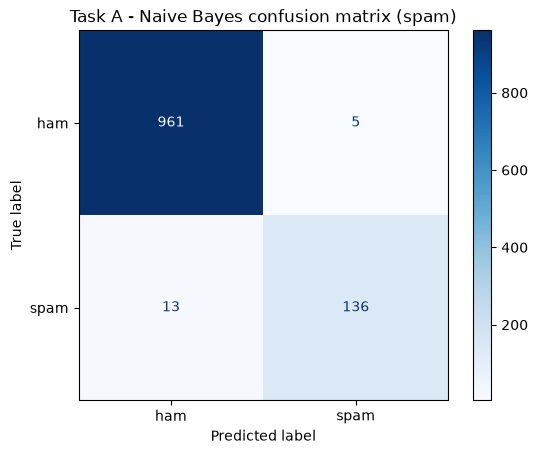

In [5]:
# Task 5 - train MultinomialNB, compute metrics, plot confusion matrix
def get_metrics(y_true, y_pred):
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred)}

nb_a = MultinomialNB()
nb_a.fit(Xa_train_vec, ya_train)
pred_a = nb_a.predict(Xa_test_vec)

metrics_nb_a = get_metrics(ya_test, pred_a)
display(pd.DataFrame(metrics_nb_a, index=['Naive Bayes (spam)']).T.round(4))

cm_a = confusion_matrix(ya_test, pred_a)
tn, fp, fn, tp = cm_a.ravel()
print(f"TN={tn} (ham kept)  FP={fp} (ham wrongly flagged as spam)  FN={fn} (spam missed)  TP={tp} (spam caught)")

ConfusionMatrixDisplay(cm_a, display_labels=['ham', 'spam']).plot(cmap='Blues')
plt.title('Task A - Naive Bayes confusion matrix (spam)')
plt.show()


## 4. Word interpretation

In [6]:
# Task 7 - top words from feature_log_prob_
vocab_a = vec_a.get_feature_names_out()
log_ratio = nb_a.feature_log_prob_[1] - nb_a.feature_log_prob_[0]   # log P(w|spam) - log P(w|ham)

top_spam_idx = np.argsort(log_ratio)[::-1][:15]
top_ham_idx = np.argsort(log_ratio)[:15]

top_spam = pd.DataFrame({'word': vocab_a[top_spam_idx],
                         'log P(w|spam) - log P(w|ham)': log_ratio[top_spam_idx].round(3),
                         'times in spam (train)': np.asarray(Xa_train_vec[ya_train.values == 1][:, top_spam_idx].sum(axis=0)).ravel(),
                         'times in ham (train)': np.asarray(Xa_train_vec[ya_train.values == 0][:, top_spam_idx].sum(axis=0)).ravel()})
top_ham = pd.DataFrame({'word': vocab_a[top_ham_idx],
                        'log P(w|spam) - log P(w|ham)': log_ratio[top_ham_idx].round(3),
                        'times in spam (train)': np.asarray(Xa_train_vec[ya_train.values == 1][:, top_ham_idx].sum(axis=0)).ravel(),
                        'times in ham (train)': np.asarray(Xa_train_vec[ya_train.values == 0][:, top_ham_idx].sum(axis=0)).ravel()})

print("15 words most associated with SPAM")
display(top_spam.reset_index(drop=True))
print("15 words most associated with HAM")
display(top_ham.reset_index(drop=True))


15 words most associated with SPAM


,word,log P(w|spam) - log P(w|ham),times in spam (train),times in ham (train)
0,claim,5.531,94,0
1,prize,5.196,67,0
2,150p,4.984,54,0
3,tone,4.827,46,0
4,18,4.714,41,0
5,cs,4.666,39,0
6,500,4.614,37,0
7,guaranteed,4.614,37,0
8,1000,4.503,33,0
9,uk,4.443,63,1


15 words most associated with HAM


,word,log P(w|spam) - log P(w|ham),times in spam (train),times in ham (train)
0,gt,-4.588,0,260
1,lt,-4.572,0,256
2,he,-4.105,0,160
3,da,-3.891,0,129
4,lor,-3.891,0,129
5,she,-3.859,0,125
6,later,-3.785,0,116
7,ll,-3.336,2,223
8,doing,-3.300,0,71
9,say,-3.272,0,69


In [7]:
# Task 8 - test your own messages (they go through the SAME clean_sms + vec_a + nb_a pipeline)
my_messages = [
    "WINNER!! You have been selected to receive a FREE $1000 prize. Call now to claim your reward!",
    "Hey, are you coming to class tomorrow? Let me know if you need my notes.",
    "Congratulations! Free entry to win a prize, text WIN to 80086 now",
    "Hi mom, I will be home late tonight, please save me some dinner",
    "Your account has a problem. Please verify your details at the link to avoid suspension",
]

results = []
for msg in my_messages:
    vec = vec_a.transform([clean_sms(msg)])
    p_spam = nb_a.predict_proba(vec)[0, 1]
    results.append({'message': msg, 'prediction': 'SPAM' if p_spam >= 0.5 else 'ham', 'P(spam)': round(p_spam, 4)})
display(pd.DataFrame(results))


,message,prediction,P(spam)
0,WINNER!! You have been selected to receive a FREE $1000 prize. Call now to claim your reward!,SPAM,1.0000
1,"Hey, are you coming to class tomorrow? Let me know if you need my notes.",ham,0.0000
2,"Congratulations! Free entry to win a prize, text WIN to 80086 now",SPAM,1.0000
3,"Hi mom, I will be home late tonight, please save me some dinner",ham,0.0000
4,Your account has a problem. Please verify your details at the link to avoid suspension,ham,0.4013
